# Notebook to analize Non-Stationary GEV for Monthly Maxima

## Import libraries

In [1]:
import numpy as np
import pandas as pd
from utils.Automatic_GEV_fit_v2_1 import GEVnonstat

## Load Skew Surge and SOI data

In [ ]:
data_path = "inputs/station_40390_SanFrancisco.parquet"
data = pd.read_parquet(f"{data_path}")
data.drop_duplicates(subset=["surge_time"], inplace=True)
data.set_index("surge_time", inplace=True)
data.index = pd.to_datetime(data.index)
data["year"] = data.index.year
data["month"] = data.index.month
data["day"] = data.index.day
data["hour"] = data.index.hour
data["minute"] = data.index.minute
data["second"] = data.index.second
data

,skew_surge,year,month,day,hour,minute,second
surge_time,,,,,,,
1950-01-01 00:00:00,0.277,1950,1,1,0,0,0
1950-01-01 08:20:00,0.110,1950,1,1,8,20,0
1950-01-01 21:40:00,0.277,1950,1,1,21,40,0
1950-01-03 03:00:00,0.065,1950,1,3,3,0,0
1950-01-03 09:40:00,0.155,1950,1,3,9,40,0
...,...,...,...,...,...,...,...
2024-12-30 03:00:00,0.501,2024,12,30,3,0,0
2024-12-30 11:10:00,0.506,2024,12,30,11,10,0
2024-12-30 23:40:00,0.254,2024,12,30,23,40,0


In [3]:
data_monthly_maxima_idxs = data.resample("M")["skew_surge"].idxmax()
data_monthly_maxima = data.loc[data_monthly_maxima_idxs]
data_monthly_maxima

/tmp/ipykernel_2865940/3831735457.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_monthly_maxima_idxs = data.resample("M")["skew_surge"].idxmax()


,skew_surge,year,month,day,hour,minute,second
surge_time,,,,,,,
1950-01-19 22:30:00,0.313,1950,1,19,22,30,0
1950-02-24 05:30:00,0.445,1950,2,24,5,30,0
1950-03-05 09:50:00,0.444,1950,3,5,9,50,0
1950-04-15 01:20:00,0.452,1950,4,15,1,20,0
1950-05-31 15:00:00,0.355,1950,5,31,15,0,0
...,...,...,...,...,...,...,...
2024-08-25 20:10:00,0.305,2024,8,25,20,10,0
2024-09-29 04:40:00,0.360,2024,9,29,4,40,0
2024-10-23 06:10:00,0.342,2024,10,23,6,10,0


<Axes: xlabel='surge_time'>

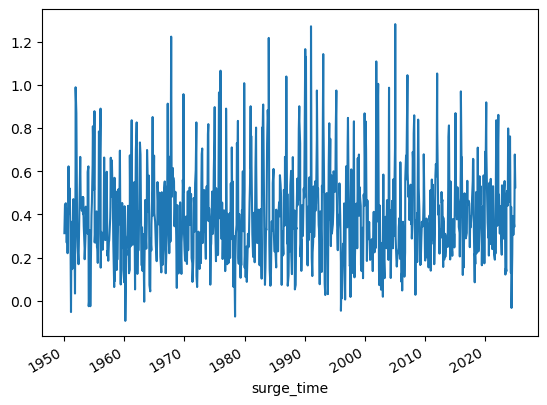

In [4]:
data_monthly_maxima.skew_surge.plot()

In [5]:
days_in_month = {
    1: 31,
    2: 28.25,
    3: 31,
    4: 30,
    5: 31,
    6: 30,
    7: 31,
    8: 31,
    9: 30,
    10: 31,
    11: 30,
    12: 31,
}
data_monthly_maxima["time"] = (
    data_monthly_maxima["year"]
    - np.min(data_monthly_maxima["year"])
    + (data_monthly_maxima["month"] - 1) / 12
    + data_monthly_maxima["day"] / data_monthly_maxima["month"].map(days_in_month) / 12
)
data_monthly_maxima

,skew_surge,year,month,day,hour,minute,second,time
surge_time,,,,,,,,
1950-01-19 22:30:00,0.313,1950,1,19,22,30,0,0.051075
1950-02-24 05:30:00,0.445,1950,2,24,5,30,0,0.154130
1950-03-05 09:50:00,0.444,1950,3,5,9,50,0,0.180108
1950-04-15 01:20:00,0.452,1950,4,15,1,20,0,0.291667
1950-05-31 15:00:00,0.355,1950,5,31,15,0,0,0.416667
...,...,...,...,...,...,...,...,...
2024-08-25 20:10:00,0.305,2024,8,25,20,10,0,74.650538
2024-09-29 04:40:00,0.360,2024,9,29,4,40,0,74.747222
2024-10-23 06:10:00,0.342,2024,10,23,6,10,0,74.811828


In [6]:
soi_index_df = pd.read_csv(
    "https://crudata.uea.ac.uk/cru/data/soi/soi.dat",
    sep=r"\s+",
    engine="python",
    names=[
        "jan",
        "feb",
        "mar",
        "apr",
        "may",
        "jun",
        "jul",
        "aug",
        "sep",
        "oct",
        "nov",
        "dec",
        "annual",
    ],
)
# Construct a monthly index
soi_index_list = []
for year in range(1950, 2025):
    soi_index_list += list(soi_index_df.loc[year].values[:12])
soi_index = {"SOI": np.array(soi_index_list)}
soi_index

{'SOI': array([ 0.54,  1.58,  1.79,  1.67,  0.55,  3.06,  2.14,  1.14,  0.63,
         1.68,  0.89,  2.46,  1.32,  0.47, -0.71, -1.03, -1.29, -0.52,
        -1.33, -0.75, -1.17, -1.44, -0.98, -0.9 , -0.92, -0.83, -0.02,
        -0.73,  0.67,  0.78,  0.51, -0.38, -0.24,  0.12, -0.22, -1.4 ,
         0.12, -0.72, -0.79, -0.18, -2.72, -0.47, -0.06, -1.89, -1.35,
        -0.18, -0.36, -0.61,  0.57, -0.52, -0.31,  0.41,  0.15, -0.49,
         0.36,  0.9 ,  0.17,  0.09,  0.16,  1.31, -0.68,  1.3 ,  0.13,
        -0.81,  0.88,  1.63,  1.8 ,  1.38,  1.4 ,  1.51,  1.38,  0.91,
         1.16,  1.1 ,  0.89,  1.06,  1.44,  1.26,  1.19,  1.05,  0.06,
         1.92,  0.11,  0.99,  0.43, -0.36, -0.37,  0.05, -1.18, -0.37,
         0.18, -1.08, -1.01, -0.09, -1.23, -0.44, -1.89, -0.78, -0.32,
         0.03, -1.39, -0.27,  0.23,  0.72, -0.34, -0.56, -0.61, -0.84,
        -0.94, -1.5 ,  0.77,  0.35,  0.14, -0.96, -0.47, -0.68, -0.01,
         0.34,  0.9 ,  0.81, -0.05, -0.25,  0.47,  0.79,  0.3 , -0.47,

## Fitting the Non Stationary GEV

In [7]:
autogev_hs2 = GEVnonstat(
    xt=data_monthly_maxima["skew_surge"].values,
    t=data_monthly_maxima["time"].values,
    example="SkewSurge Monthly",
    trends=False,
    harm=True,
    covariates=soi_index,
)

# Fit the GEV model
(
    beta0,
    beta,
    alpha0,
    alpha,
    gamma0,
    gamma,
    betaT,
    auxvarphi_loc,
    list_loc,
    betaT2,
    auxvarphi_sc,
    list_sc,
    auxvarphi_sh,
    list_sh,
    loglikeobj,
    grad,
    hessian,
    popt,
    stdpara,
) = autogev_hs2.AutoAdjust()

Starting the Harmonic iterative process


  3%|▎         | 3/100 [10:42<5:46:07, 214.09s/it]


End of the Harmonic iterative process
Harmonic GEV AIC: -499.38690610239564 

Starting the Covariates iterative process


Covariate Iteration:   0%|          | 0/3 [00:01<?, ?it/s]


End of the Covariates iterative process
Covariates AIC: -499.38690610239564 



In [10]:
print("Location parameter (mu)")
print("beta0", beta0)
print("beta", beta)
print("betaT", betaT)
print("varphi", auxvarphi_loc)
print("--------------------------")
print("Scale parameter (sigma)")
print("alpha0", alpha0)
print("alpha", alpha)
print("betaT2", betaT2)
print("varphi2", auxvarphi_sc)
print("--------------------------")
print("Shape parameter (xi)")
print("gamma0", gamma0)
print("gamma", gamma)
print("varphi3", auxvarphi_sh)

Location parameter (mu)
beta0 0.3047551686104231
beta [ 0.0710966 -0.0616943]
betaT None
varphi []
--------------------------
Scale parameter (sigma)
alpha0 -1.7942079051898954
alpha [ 0.38973586 -0.00713105]
betaT2 None
varphi2 []
--------------------------
Shape parameter (xi)
gamma0 None
gamma None
varphi3 []


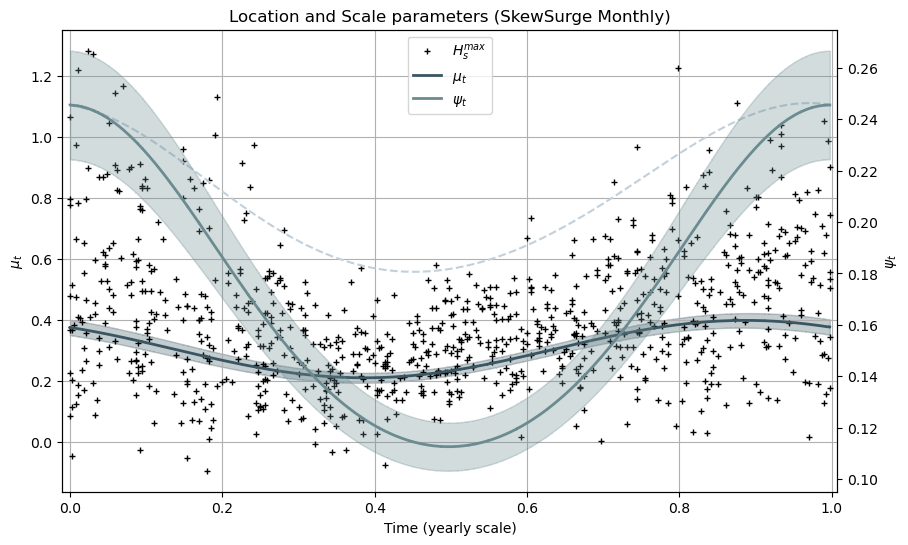

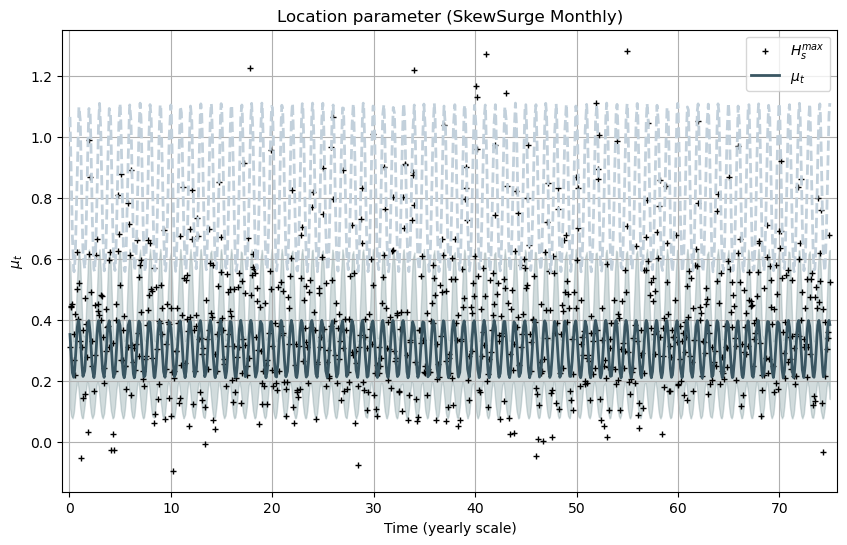

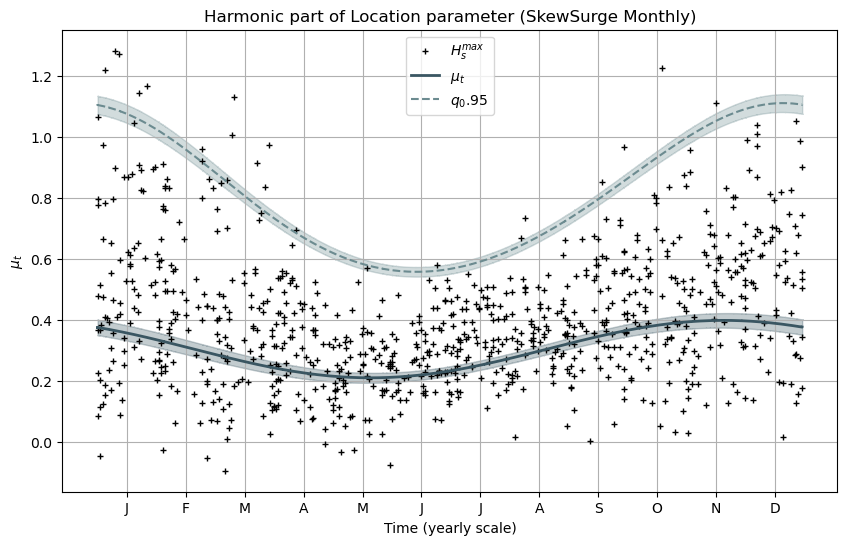

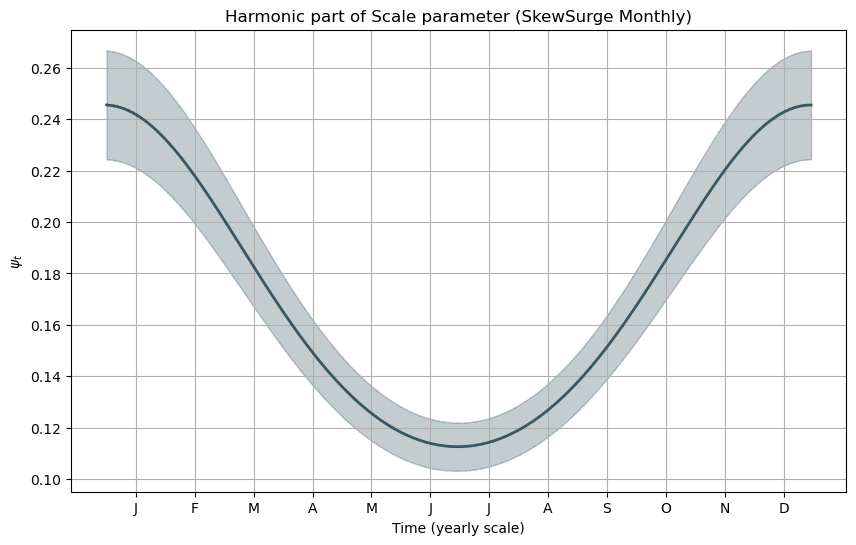

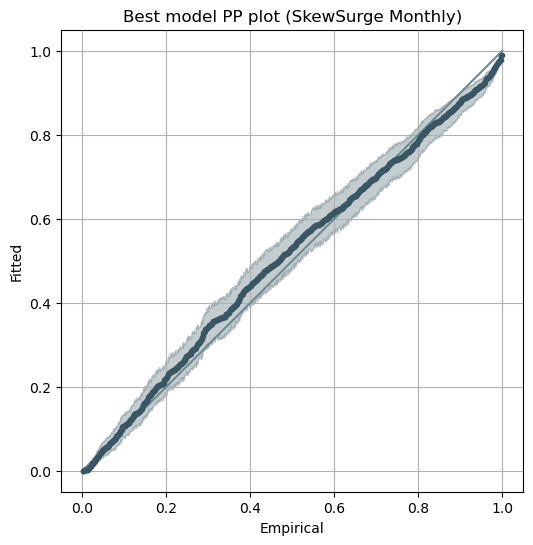

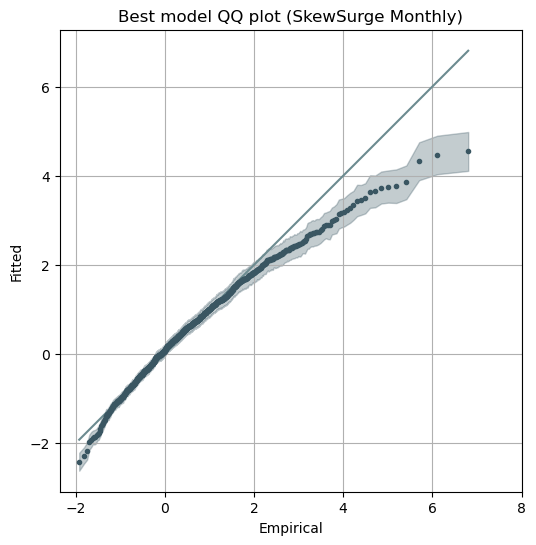

TypeError: only length-1 arrays can be converted to Python scalars

In [11]:
autogev_hs2.plot()